In [1]:
# PROJECT: Global Inflation Analysis 2000–2023
# Countries: Nigeria, Ghana, Kenya, Egypt, South Africa,
#            Turkey, Brazil, India, Argentina,
#            USA, Germany, France,
#            Zimbabwe, Venezuela, Japan
#
# Data Source: World Bank — FP.CPI.TOTL.ZG
# Pipeline: Python (clean) → SQL (query) → Power BI (dashboard)
# Story: How did inflation hit differently — and what can we learn?

Instead of all 190+ countries, I have selected 15 countries across 5 groups. Each group tells part of a bigger story:

Group 1 — African Focus (My Personal Angle)
Nigeria, Ghana, Kenya, Egypt, South Africa

Group 2 — Emerging Markets (For Comparison)
Turkey, Brazil, India, Argentina

Group 3 — Stable Developed Economies (The Benchmark)
USA, Germany, France

Group 4 — Extreme Case Studies
Zimbabwe, Venezuela, Japan

Extreme Cases includes both hyperinflationary economies (Zimbabwe, Venezuela) and Japan, which represents the deflationary extreme, a phenomenon equally rare and consequential.

In [3]:
import pandas as pd

df = pd.read_csv("/content/Inflation Data.csv", skiprows=4)
print(df.shape)
print(df.columns.tolist())
df.head()

(266, 71)
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,NaN,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN


**Data Cleaning**

In [4]:
## Drop unwanted columns
df= df.drop(columns=['Indicator Name', 'Indicator Code', 'Unnamed: 70', '2025'])

print(df.shape)
print(df.columns.tolist)

(266, 67)
<bound method IndexOpsMixin.tolist of Index(['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964',
       '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973',
       '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982',
       '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')>


In [5]:
## Countries necessary for the analysis as discussed above
countries = [
    'Nigeria', 'Ghana', 'Kenya', 'Egypt, Arab Rep.', 'South Africa',
    'Turkiye', 'Brazil', 'India', 'Argentina',
    'United States', 'Germany', 'France',
    'Zimbabwe', 'Venezuela, RB', 'Japan'
]

df_filtered = df[df['Country Name'].isin(countries)]

print(df_filtered.shape)
print(df_filtered['Country Name'].unique())

(15, 67)
['Argentina' 'Brazil' 'Germany' 'Egypt, Arab Rep.' 'France' 'Ghana'
 'India' 'Japan' 'Kenya' 'Nigeria' 'Turkiye' 'United States'
 'Venezuela, RB' 'South Africa' 'Zimbabwe']


In [6]:
## Reshaping dataset
df_long = df_filtered.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Inflation_Rate'
)

# Convert Year to integer and Inflation to float
df_long['Year'] = df_long['Year'].astype(int)
df_long['Inflation_Rate'] = pd.to_numeric(df_long['Inflation_Rate'], errors='coerce')

# Rename for cleanliness
df_long = df_long.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})

print(df_long.shape)
df_long.head(15)

(975, 4)


,country,country_code,Year,Inflation_Rate
0,Argentina,ARG,1960,NaN
1,Brazil,BRA,1960,NaN
2,Germany,DEU,1960,1.536612
3,"Egypt, Arab Rep.",EGY,1960,0.332829
4,France,FRA,1960,4.139936
5,Ghana,GHA,1960,NaN
6,India,IND,1960,1.779878
7,Japan,JPN,1960,3.574512
8,Kenya,KEN,1960,1.243781
9,Nigeria,NGA,1960,5.444327


In [7]:
## Adding Region map
region_map = {
    'Nigeria': 'Africa',
    'Ghana': 'Africa',
    'Kenya': 'Africa',
    'Egypt, Arab Rep.': 'Africa',
    'South Africa': 'Africa',
    'Turkiye': 'Emerging Markets',
    'Brazil': 'Emerging Markets',
    'India': 'Emerging Markets',
    'Argentina': 'Emerging Markets',
    'United States': 'Developed',
    'Germany': 'Developed',
    'France': 'Developed',
    'Zimbabwe': 'Extreme Cases',
    'Venezuela, RB': 'Extreme Cases',
    'Japan': 'Extreme Cases'
}

df_long['region'] = df_long['country'].map(region_map)

print(df_long['region'].value_counts())
df_long.head()

region
Africa              325
Emerging Markets    260
Developed           195
Extreme Cases       195
Name: count, dtype: int64


,country,country_code,Year,Inflation_Rate,region
0,Argentina,ARG,1960,NaN,Emerging Markets
1,Brazil,BRA,1960,NaN,Emerging Markets
2,Germany,DEU,1960,1.536612,Developed
3,"Egypt, Arab Rep.",EGY,1960,0.332829,Africa
4,France,FRA,1960,4.139936,Developed


In [8]:
## Checking missing values per country
missing = df_long.groupby('country')['Inflation_Rate'].apply(
    lambda x: x.isna().sum()
).reset_index()
missing.columns = ['country', 'missing_years']
missing = missing.sort_values('missing_years', ascending=False)
print(missing)

             country  missing_years
0          Argentina             58
13     Venezuela, RB             57
14          Zimbabwe             52
1             Brazil             21
5              Ghana              5
2   Egypt, Arab Rep.              0
3             France              0
6              India              0
4            Germany              0
7              Japan              0
8              Kenya              0
10      South Africa              0
9            Nigeria              0
12     United States              0
11           Turkiye              0


In [9]:
# The project's focus is on 2000-2024
df_analysis = df_long[df_long['Year'] >= 2000].copy()

print(f"Rows after filtering: {len(df_analysis)}")
print(f"Years covered: {df_analysis['Year'].min()} to {df_analysis['Year'].max()}")

# Final missing value check
missing_final = df_analysis.groupby('country')['Inflation_Rate'].apply(
    lambda x: x.isna().sum()
).reset_index()
missing_final.columns = ['country', 'missing_years']
print("\nMissing values per country (2000-2024):")
print(missing_final.sort_values('missing_years', ascending=False))

Rows after filtering: 375
Years covered: 2000 to 2024

Missing values per country (2000-2024):
             country  missing_years
0          Argentina             18
13     Venezuela, RB             17
14          Zimbabwe             12
3             France              0
4            Germany              0
1             Brazil              0
2   Egypt, Arab Rep.              0
6              India              0
5              Ghana              0
7              Japan              0
8              Kenya              0
10      South Africa              0
9            Nigeria              0
12     United States              0
11           Turkiye              0


**Country Selection — Adjustments and Reasoning**

An initial inspection of missing values revealed that three originally selected countries (Argentina, Venezuela, and Zimbabwe) had significant data gaps in the 2000–2024 window.

### Countries Removed

**Argentina (18 out of 25 years missing)**

Argentina was removed from the core analysis due to an overwhelming number of missing
values in the World Bank CPI dataset. Historically, between
2007 and 2015, Argentina's government was formally censured by the IMF for deliberately
misreporting its inflation statistics. As a result, international institutions including
the World Bank stopped recording its figures as reliable. Including Argentina would mean
building analysis on a foundation of politically manipulated and largely absent data,
which would undermine the integrity of the findings.

**Venezuela (17 out of 25 years missing)**

Venezuela was removed for similar reasons. As the country's economic and political crisis
deepened from 2014 onwards, the government ceased publishing credible economic data
entirely. The World Bank gaps reflects the collapse of a
functioning national statistical system. Venezuela's hyperinflation story is real and
significant, however, it cannot be responsibly told with the data available here.

### Countries Added as Replacements

**South Korea (replacing Argentina)**

South Korea was selected as a replacement emerging market because it represents one of
the most successful cases of inflation management in the developing world over the past
25 years. Where Argentina's story is one of instability and data absence, South Korea
offers a complete, credible dataset and a compelling counterpoint, an emerging economy
that kept inflation largely under control even through the 2008 global financial crisis
and the 2021–2023 post-COVID spike. This contrast strengthens the analytical depth of
the emerging markets group.

**Pakistan (replacing Venezuela)**

Pakistan was selected to maintain representation of chronic high-inflation emerging
economies which was the role Venezuela was originally meant to fill. Pakistan has experienced
persistent and well-documented inflationary pressure throughout the 2000–2024 period,
with particularly sharp spikes in 2008, 2019, and 2022–2023. Crucially, its data is
complete and reliable, making it a far more analytically useful case study of a
struggling emerging economy than Venezuela's absent figures could provide.

#### Special Cases Group — Addition of Ethiopia

**Ethiopia (added alongside Zimbabwe and Japan)**

Ethiopia was added to the Special Cases group to strengthen the Africa in Focus narrative
and to provide a counterpoint to Zimbabwe within the African continent. While Zimbabwe
represents economic collapse and hyperinflation, Ethiopia represents rapid growth, it
was one of the world's fastest-growing economies for much of the 2000s and 2010s.
Its inflation story is nuanced: high growth brought high inflation, peaking sharply in
2008 and again in 2022. Ethiopia also has complete data for the analysis period, which
Zimbabwe partially lacks. Together, Zimbabwe and Ethiopia show that Africa's inflation
story is not one-dimensional as it contains both cautionary tales and growth narratives,
often existing on the same continent at the same time.

**Final Country List**

| Group            | Countries                                              |
|------------------|--------------------------------------------------------|
| Africa           | Nigeria, Ghana, Kenya, Egypt, South Africa             |
| Emerging Markets | Turkey, Brazil, India, South Korea, Pakistan           |
| Developed        | USA, Germany, France                                   |
| Special Cases    | Zimbabwe, Japan, Ethiopia                              |

In [10]:
countries_updated = [
    'Nigeria', 'Ghana', 'Kenya', 'Egypt, Arab Rep.', 'South Africa',
    'Turkiye', 'Brazil', 'India', 'Korea, Rep.', 'Pakistan',
    'United States', 'Germany', 'France',
    'Zimbabwe', 'Japan', 'Ethiopia'
]

# Refiltering the original dataframe
df_filtered = df[df['Country Name'].isin(countries_updated)]
print(f"Countries found: {df_filtered['Country Name'].nunique()}")
print(df_filtered['Country Name'].unique())

Countries found: 16
['Brazil' 'Germany' 'Egypt, Arab Rep.' 'Ethiopia' 'France' 'Ghana' 'India'
 'Japan' 'Kenya' 'Korea, Rep.' 'Nigeria' 'Pakistan' 'Turkiye'
 'United States' 'South Africa' 'Zimbabwe']


In [11]:
# Melt to long format
df_long = df_filtered.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Inflation_Rate'
)

df_long['Year'] = df_long['Year'].astype(int)
df_long['Inflation_Rate'] = pd.to_numeric(df_long['Inflation_Rate'], errors='coerce')
df_long = df_long.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})

# Updated region map
region_map = {
    'Nigeria': 'Africa',
    'Ghana': 'Africa',
    'Kenya': 'Africa',
    'Egypt, Arab Rep.': 'Africa',
    'South Africa': 'Africa',
    'Turkiye': 'Emerging Markets',
    'Brazil': 'Emerging Markets',
    'India': 'Emerging Markets',
    'Korea, Rep.': 'Emerging Markets',
    'Pakistan': 'Emerging Markets',
    'United States': 'Developed',
    'Germany': 'Developed',
    'France': 'Developed',
    'Zimbabwe': 'Special Cases',
    'Japan': 'Special Cases',
    'Ethiopia': 'Special Cases'
}

df_long['region'] = df_long['country'].map(region_map)

# Filter to 2000-2024
df_analysis = df_long[df_long['Year'] >= 2000].copy()

# Add display names
display_names = {
    'Turkiye': 'Turkey',
    'Egypt, Arab Rep.': 'Egypt',
    'Korea, Rep.': 'South Korea',
    'United States': 'USA'
}
df_analysis['country_display'] = df_analysis['country'].map(display_names)
df_analysis['country_display'] = df_analysis['country_display'].fillna(df_analysis['country'])

# Final check
print(f"\nShape: {df_analysis.shape}")
print(f"Countries: {df_analysis['country_display'].nunique()}")
print(f"\nMissing values per country:")
missing_check = df_analysis.groupby('country_display')['Inflation_Rate'].apply(
    lambda x: x.isna().sum()
).reset_index()
missing_check.columns = ['country', 'missing_years']
print(missing_check.sort_values('missing_years', ascending=False))


Shape: (400, 6)
Countries: 16

Missing values per country:
         country  missing_years
15      Zimbabwe             12
0         Brazil              0
2       Ethiopia              0
1          Egypt              0
4        Germany              0
5          Ghana              0
6          India              0
3         France              0
7          Japan              0
8          Kenya              0
10      Pakistan              0
9        Nigeria              0
11  South Africa              0
12   South Korea              0
13        Turkey              0
14           USA              0


### Save CSV and SQLite

In [12]:
import sqlite3

# Save clean CSV for Power BI later
df_analysis.to_csv('inflation_clean.csv', index=False)

# Save to SQLite for SQL analysis
conn_inflation = sqlite3.connect('inflation.db')
df_analysis.to_sql(
    'inflation_data',
    conn_inflation,
    if_exists='replace',
    index=False
)
conn_inflation.close()

print("inflation_clean.csv saved")
print("inflation.db saved")
print(f"   Table: inflation_data")
print(f"   Rows: {len(df_analysis)}")
print(f"\nColumns in your database:")
print(df_analysis.columns.tolist())

inflation_clean.csv saved
inflation.db saved
   Table: inflation_data
   Rows: 400

Columns in your database:
['country', 'country_code', 'Year', 'Inflation_Rate', 'region', 'country_display']


In [13]:
# Reconnecting in the same pattern as the sales database
conn_inflation = sqlite3.connect('inflation.db')

# First 10 rows
pd.read_sql_query("""
    SELECT *
    FROM inflation_data
    LIMIT 10
""", conn_inflation)

,country,country_code,Year,Inflation_Rate,region,country_display
0,Brazil,BRA,2000,7.044141,Emerging Markets,Brazil
1,Germany,DEU,2000,1.440268,Developed,Germany
2,"Egypt, Arab Rep.",EGY,2000,2.683805,Africa,Egypt
3,Ethiopia,ETH,2000,0.662458,Special Cases,Ethiopia
4,France,FRA,2000,1.675960,Developed,France
5,Ghana,GHA,2000,40.240933,Africa,Ghana
6,India,IND,2000,4.009436,Emerging Markets,India
7,Japan,JPN,2000,-0.676579,Special Cases,Japan
8,Kenya,KEN,2000,9.980025,Africa,Kenya
9,"Korea, Rep.",KOR,2000,2.259166,Emerging Markets,South Korea


### THE WORST YEARS

In [14]:
## Which country had the highest inflation in each year, and how many times did each country top the chart?
pd.read_sql_query("""
    SELECT
        country,
        COUNT(*) AS times_top
    FROM (
        SELECT
            country,
            Year,
            Inflation_Rate,
            ROW_NUMBER() OVER (PARTITION BY Year ORDER BY Inflation_Rate DESC) AS rn
        FROM inflation_data
        WHERE Inflation_Rate IS NOT NULL
    )
    WHERE rn = 1
    GROUP BY country
    ORDER BY times_top DESC
""", conn_inflation)

,country,times_top
0,Ghana,7
1,Turkiye,6
2,Zimbabwe,4
3,Ethiopia,4
4,Nigeria,2
5,Kenya,1
6,"Egypt, Arab Rep.",1


In [15]:
## Which country-year combinations had inflation above 20%? How many times did each country breach that threshold?
pd.read_sql_query("""
    SELECT
        country,
        Year,
        ROUND(Inflation_Rate, 2) AS Inflation_Rate
    FROM inflation_data
    WHERE Inflation_Rate > 20
    AND Inflation_Rate IS NOT NULL
    ORDER BY Inflation_Rate DESC
""", conn_inflation)

,country,Year,Inflation_Rate
0,Zimbabwe,2020,557.20
1,Zimbabwe,2019,255.30
2,Zimbabwe,2022,104.71
3,Zimbabwe,2021,98.55
4,Turkiye,2022,72.31
5,Turkiye,2024,58.51
6,Turkiye,2000,54.92
7,Turkiye,2001,54.40
8,Turkiye,2023,53.86
9,Turkiye,2002,44.96


In [16]:
pd.read_sql_query("""
    SELECT
        country,
        COUNT(*) AS crisis_years,
        ROUND(MAX(Inflation_Rate), 2) AS worst_inflation,
        MIN(Year) AS first_crisis_year,
        MAX(Year) AS latest_crisis_year
    FROM inflation_data
    WHERE Inflation_Rate > 20
    AND Inflation_Rate IS NOT NULL
    GROUP BY country
    ORDER BY crisis_years DESC
""", conn_inflation)

,country,crisis_years,worst_inflation,first_crisis_year,latest_crisis_year
0,Ethiopia,8,44.36,2008,2024
1,Turkiye,7,72.31,2000,2024
2,Ghana,6,41.51,2000,2024
3,Zimbabwe,4,557.20,2019,2022
4,"Egypt, Arab Rep.",3,33.88,2017,2024
5,Pakistan,2,30.77,2008,2023
6,Nigeria,2,33.24,2023,2024
7,Kenya,1,26.24,2008,2008


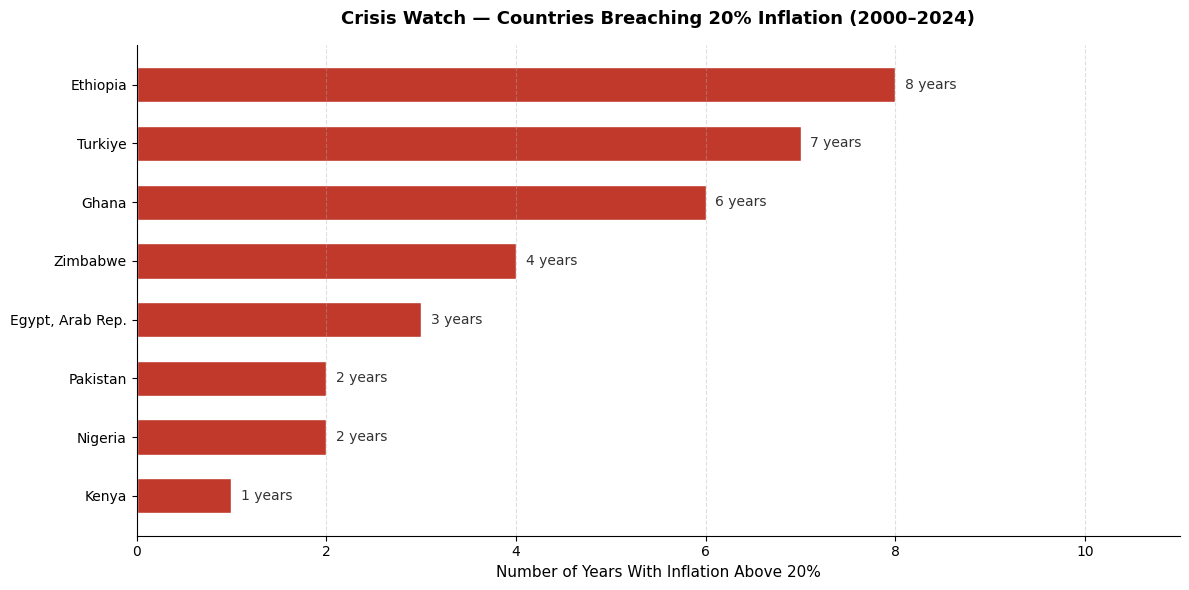

Chart saved: crisis_watch.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Pull the data into a dataframe for charting
df_crisis = pd.read_sql_query("""
    SELECT
        country,
        COUNT(*) AS crisis_years,
        ROUND(MAX(Inflation_Rate), 2) AS worst_inflation
    FROM inflation_data
    WHERE Inflation_Rate > 20
    AND Inflation_Rate IS NOT NULL
    GROUP BY country
    ORDER BY crisis_years DESC
""", conn_inflation)

# Build the chart
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    df_crisis['country'],
    df_crisis['crisis_years'],
    color='#C0392B',
    edgecolor='white',
    height=0.6
)

# Add value labels on each bar
for bar, val in zip(bars, df_crisis['crisis_years']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(val)} years',
        va='center',
        fontsize=10,
        color='#333333'
    )

ax.set_xlabel('Number of Years With Inflation Above 20%', fontsize=11)
ax.set_title('Crisis Watch — Countries Breaching 20% Inflation (2000–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, df_crisis['crisis_years'].max() + 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('crisis_watch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: crisis_watch.png")

### The Stability Award

In [18]:
## Which countries kept inflation below 5% most consistently across the full 25 years?
pd.read_sql_query("""
    SELECT
        country,
        COUNT(*) AS stable_years,
        ROUND(AVG(Inflation_Rate), 2) AS avg_inflation,
        ROUND(MAX(Inflation_Rate), 2) AS highest_stable_rate
    FROM inflation_data
    WHERE Inflation_Rate < 5
    AND Inflation_Rate IS NOT NULL
    GROUP BY country
    ORDER BY stable_years DESC
""", conn_inflation)

,country,stable_years,avg_inflation,highest_stable_rate
0,Japan,25,0.41,3.27
1,United States,24,2.35,4.70
2,"Korea, Rep.",24,2.39,4.67
3,France,24,1.56,4.88
4,Germany,23,1.51,3.07
5,India,12,4.14,4.95
6,South Africa,10,3.40,4.62
7,Brazil,9,3.97,4.89
8,Zimbabwe,8,1.07,3.73
9,Pakistan,7,3.44,4.37


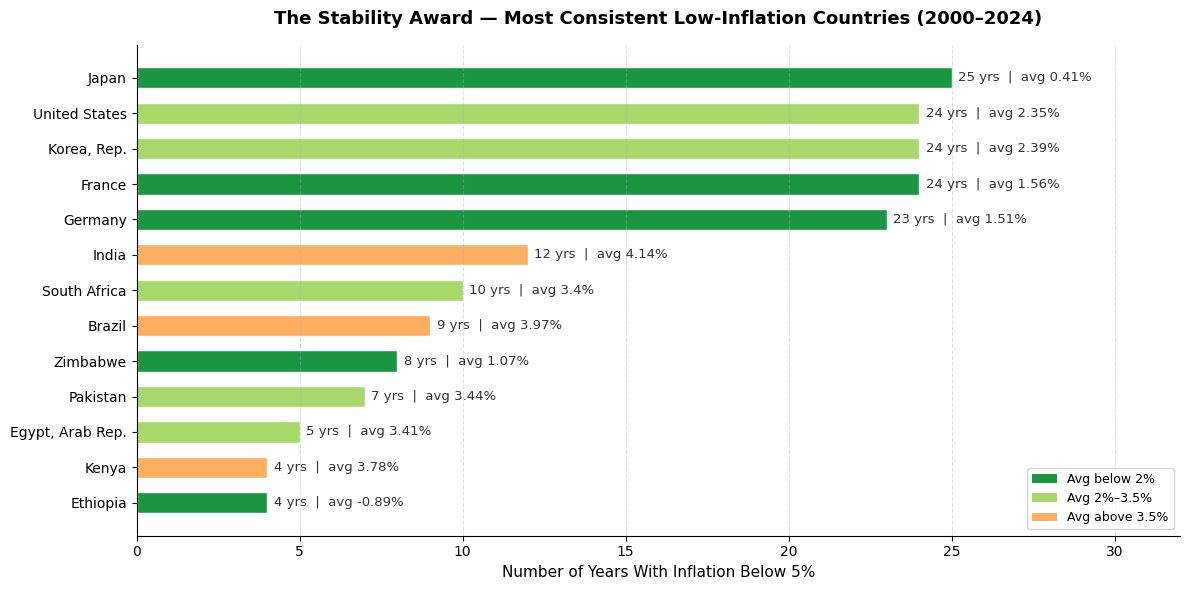

Chart saved: stability_award.png


In [19]:
# Pull data for chart
df_stable = pd.read_sql_query("""
    SELECT
        country,
        COUNT(*) AS stable_years,
        ROUND(AVG(Inflation_Rate), 2) AS avg_inflation
    FROM inflation_data
    WHERE Inflation_Rate < 5
    AND Inflation_Rate IS NOT NULL
    GROUP BY country
    ORDER BY stable_years DESC
""", conn_inflation)

fig, ax = plt.subplots(figsize=(12, 6))

# Colour bars by average inflation where greener means more stable
colors = ['#1a9641' if x < 2 else '#a6d96a' if x < 3.5 else '#fdae61'
          for x in df_stable['avg_inflation']]

bars = ax.barh(
    df_stable['country'],
    df_stable['stable_years'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Adding labels showing both stable years and average inflation
for bar, years, avg in zip(bars, df_stable['stable_years'],
                            df_stable['avg_inflation']):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{int(years)} yrs  |  avg {avg}%',
        va='center',
        fontsize=9.5,
        color='#333333'
    )

ax.set_xlabel('Number of Years With Inflation Below 5%', fontsize=11)
ax.set_title('The Stability Award — Most Consistent Low-Inflation Countries (2000–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, df_stable['stable_years'].max() + 7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a9641', label='Avg below 2%'),
    Patch(facecolor='#a6d96a', label='Avg 2%–3.5%'),
    Patch(facecolor='#fdae61', label='Avg above 3.5%')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('stability_award.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: stability_award.png")

## The Africa Report

In [20]:
pd.read_sql_query("""
SELECT
    country,
    CASE
        WHEN Year BETWEEN 2000 AND 2009 THEN '2000s'
        WHEN Year BETWEEN 2010 AND 2019 THEN '2010s'
        ELSE '2020s'
    END AS Decade,
    ROUND(AVG(Inflation_Rate), 2) AS avg_inflation
FROM inflation_data
WHERE region = 'Africa'
GROUP BY country, Decade
ORDER BY country, Decade
""", conn_inflation)

,country,Decade,avg_inflation
0,"Egypt, Arab Rep.",2000s,7.54
1,"Egypt, Arab Rep.",2010s,12.52
2,"Egypt, Arab Rep.",2020s,17.26
3,Ghana,2000s,21.25
4,Ghana,2010s,11.97
5,Ghana,2020s,22.41
6,Kenya,2000s,10.91
7,Kenya,2010s,7.08
8,Kenya,2020s,6.27
9,Nigeria,2000s,12.33


Decade           country  2000s  2010s  2020s
0       Egypt, Arab Rep.   7.54  12.52  17.26
1                  Ghana  21.25  11.97  22.41
2                  Kenya  10.91   7.08   6.27
3                Nigeria  12.33  11.80  21.39
4           South Africa   5.42   5.16   5.07


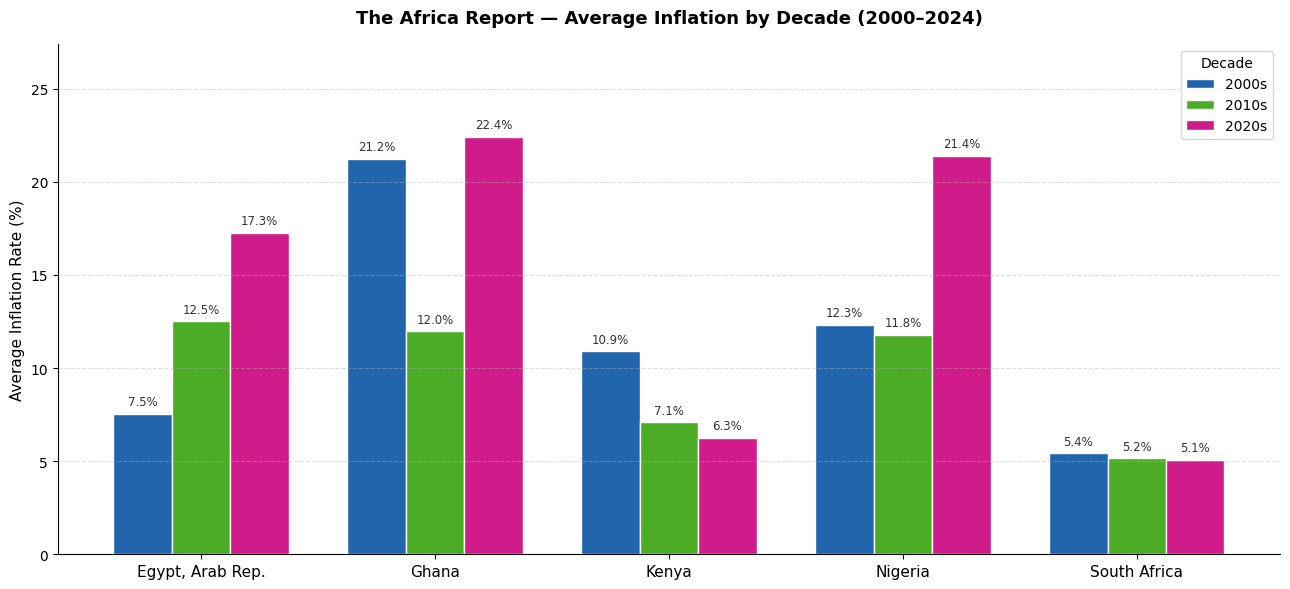

Chart saved: africa_report.png


In [21]:
import numpy as np

# Pull data
df_africa = pd.read_sql_query("""
    SELECT
        country,
        CASE
            WHEN Year BETWEEN 2000 AND 2009 THEN '2000s'
            WHEN Year BETWEEN 2010 AND 2019 THEN '2010s'
            ELSE '2020s'
        END AS Decade,
        ROUND(AVG(Inflation_Rate), 2) AS avg_inflation
    FROM inflation_data
    WHERE region = 'Africa'
    AND Inflation_Rate IS NOT NULL
    GROUP BY country, Decade
    ORDER BY country, Decade
""", conn_inflation)

# Pivot so each decade becomes its own column
df_pivot = df_africa.pivot(
    index='country',
    columns='Decade',
    values='avg_inflation'
).reset_index()

print(df_pivot)

# Chart setup
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(df_pivot['country']))
width = 0.25
decade_colors = {
    '2000s': '#2166ac',
    '2010s': '#4dac26',
    '2020s': '#d01c8b'
}

# Drawing one group of bars per decade
for i, decade in enumerate(['2000s', '2010s', '2020s']):
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset,
        df_pivot[decade],
        width,
        label=decade,
        color=decade_colors[decade],
        edgecolor='white'
    )
    # Adding value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8.5,
                color='#333333'
            )

ax.set_xticks(x)
ax.set_xticklabels(df_pivot['country'], fontsize=11)
ax.set_ylabel('Average Inflation Rate (%)', fontsize=11)
ax.set_title('The Africa Report — Average Inflation by Decade (2000–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Decade', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, df_africa['avg_inflation'].max() + 5)

plt.tight_layout()
plt.savefig('africa_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: africa_report.png")

### Turkiye vs Nigeria

In [22]:
## Year by year, side by side, who had higher inflation more often, and what is the average gap between them?
pd.read_sql_query("""
    SELECT
        nga.Year,
        ROUND(nga.Inflation_Rate, 2) AS Nigeria_Rate,
        ROUND(tky.Inflation_Rate, 2) AS Turkey_Rate,
        ROUND(tky.Inflation_Rate - nga.Inflation_Rate, 2) AS difference
    FROM inflation_data nga
    JOIN inflation_data tky
        ON nga.Year = tky.Year          -- match on year
    WHERE nga.country = 'Nigeria'        -- left side filter
    AND tky.country = 'Turkiye'          -- right side filter
    AND nga.Inflation_Rate IS NOT NULL
    AND tky.Inflation_Rate IS NOT NULL
    ORDER BY nga.Year
""", conn_inflation)

,Year,Nigeria_Rate,Turkey_Rate,difference
0,2000,6.93,54.92,47.98
1,2001,18.87,54.40,35.53
2,2002,12.88,44.96,32.09
3,2003,14.03,21.60,7.57
4,2004,15.00,8.60,-6.40
5,2005,17.86,8.18,-9.68
6,2006,8.23,9.60,1.37
7,2007,5.39,8.76,3.37
8,2008,11.58,10.44,-1.14
9,2009,12.54,6.25,-6.29


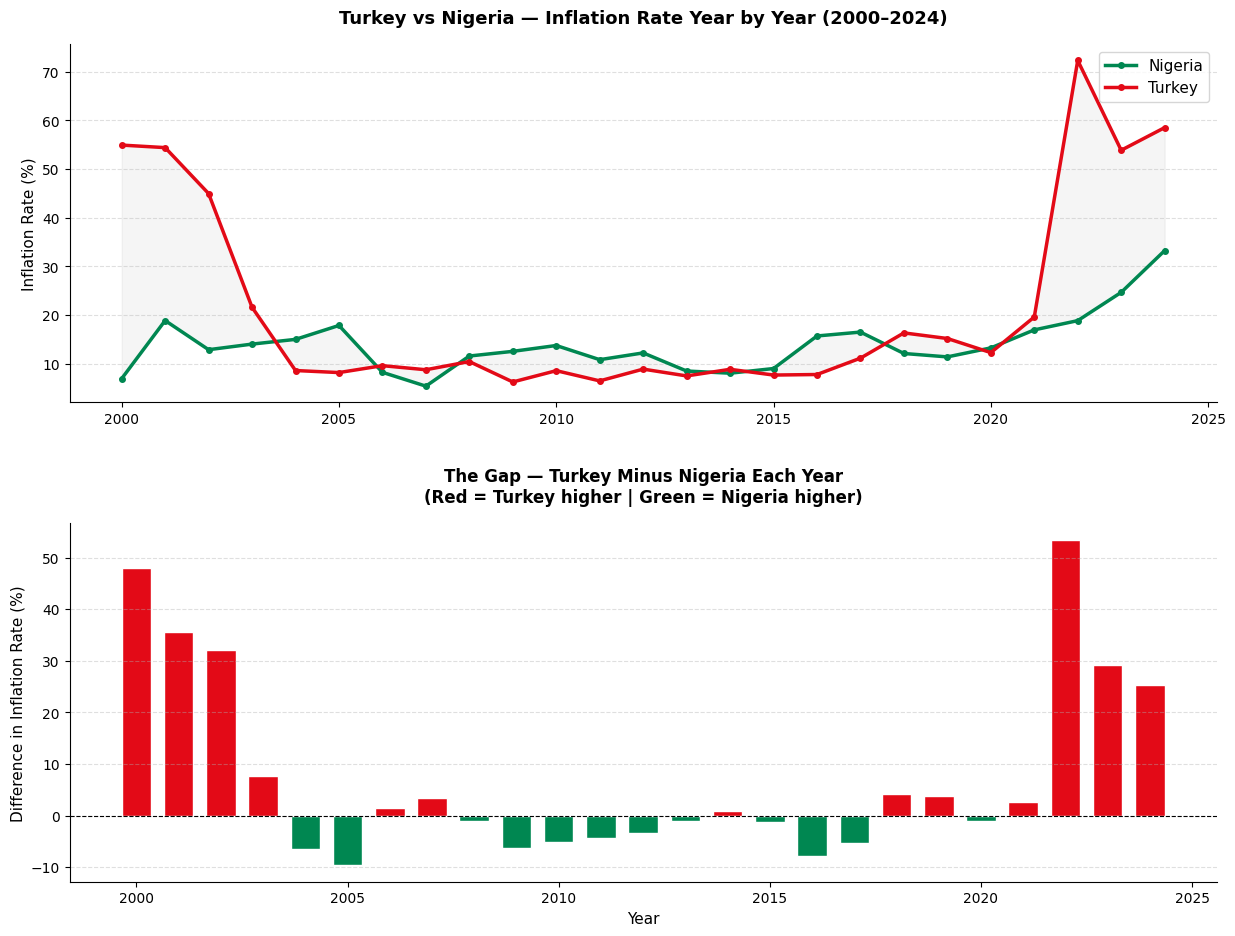

Chart saved: turkey_vs_nigeria.png


In [23]:
df_comparison = pd.read_sql_query("""
    SELECT
        nga.Year,
        ROUND(nga.Inflation_Rate, 2) AS Nigeria_Rate,
        ROUND(tky.Inflation_Rate, 2) AS Turkey_Rate,
        ROUND(tky.Inflation_Rate - nga.Inflation_Rate, 2) AS difference
    FROM inflation_data nga
    JOIN inflation_data tky ON nga.Year = tky.Year
    WHERE nga.country = 'Nigeria'
    AND tky.country = 'Turkiye'
    AND nga.Inflation_Rate IS NOT NULL
    AND tky.Inflation_Rate IS NOT NULL
    ORDER BY nga.Year
""", conn_inflation)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))

# TOP CHART: Side by side line chart
ax1.plot(df_comparison['Year'], df_comparison['Nigeria_Rate'],
         color='#008751', linewidth=2.5, marker='o',
         markersize=4, label='Nigeria')
ax1.plot(df_comparison['Year'], df_comparison['Turkey_Rate'],
         color='#E30A17', linewidth=2.5, marker='o',
         markersize=4, label='Turkey')

ax1.fill_between(df_comparison['Year'],
                 df_comparison['Nigeria_Rate'],
                 df_comparison['Turkey_Rate'],
                 alpha=0.08, color='gray')

ax1.set_title('Turkey vs Nigeria — Inflation Rate Year by Year (2000–2024)',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Inflation Rate (%)', fontsize=11)
ax1.legend(fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# BOTTOM CHART: The gap (difference)
colors_diff = ['#E30A17' if x > 0 else '#008751'
               for x in df_comparison['difference']]

ax2.bar(df_comparison['Year'],
        df_comparison['difference'],
        color=colors_diff,
        edgecolor='white',
        width=0.7)

ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('The Gap — Turkey Minus Nigeria Each Year\n'
              '(Red = Turkey higher | Green = Nigeria higher)',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('Difference in Inflation Rate (%)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(pad=3.0)
plt.savefig('turkey_vs_nigeria.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: turkey_vs_nigeria.png")

### The Full Picture

In [24]:
pd.read_sql_query("""
    SELECT
        country,
        region,
        Year,
        ROUND(Inflation_Rate, 2) AS inflation,
        ROUND(AVG(Inflation_Rate) OVER (PARTITION BY region, Year), 2)
            AS regional_avg,
        ROUND(Inflation_Rate - AVG(Inflation_Rate)
            OVER (PARTITION BY region, Year), 2) AS deviation
    FROM inflation_data
    WHERE Inflation_Rate IS NOT NULL
    ORDER BY region, country, Year
""", conn_inflation)

,country,region,Year,inflation,regional_avg,deviation
0,"Egypt, Arab Rep.",Africa,2000,2.68,13.04,-10.35
1,"Egypt, Arab Rep.",Africa,2001,2.27,14.82,-12.55
2,"Egypt, Arab Rep.",Africa,2002,2.74,7.29,-4.55
3,"Egypt, Arab Rep.",Africa,2003,4.51,12.76,-8.25
4,"Egypt, Arab Rep.",Africa,2004,11.27,11.05,0.22
...,...,...,...,...,...,...
383,Zimbabwe,Special Cases,2018,10.62,8.48,2.14
384,Zimbabwe,Special Cases,2019,255.30,90.53,164.78
385,Zimbabwe,Special Cases,2020,557.20,192.51,364.69
386,Zimbabwe,Special Cases,2021,98.55,41.72,56.83


In [25]:
## Nigeria Focus
pd.read_sql_query("""
    SELECT
        country,
        region,
        Year,
        ROUND(Inflation_Rate, 2) AS inflation,
        ROUND(AVG(Inflation_Rate) OVER (PARTITION BY region, Year), 2)
            AS regional_avg
    FROM inflation_data
    WHERE Inflation_Rate IS NOT NULL
    AND country = 'Nigeria'
    ORDER BY Year
""", conn_inflation)

,country,region,Year,inflation,regional_avg
0,Nigeria,Africa,2000,6.93,6.93
1,Nigeria,Africa,2001,18.87,18.87
2,Nigeria,Africa,2002,12.88,12.88
3,Nigeria,Africa,2003,14.03,14.03
4,Nigeria,Africa,2004,15.00,15.00
5,Nigeria,Africa,2005,17.86,17.86
6,Nigeria,Africa,2006,8.23,8.23
7,Nigeria,Africa,2007,5.39,5.39
8,Nigeria,Africa,2008,11.58,11.58
9,Nigeria,Africa,2009,12.54,12.54


In [26]:
## Turkey Focus
pd.read_sql_query("""
    SELECT
        country,
        region,
        Year,
        ROUND(Inflation_Rate, 2) AS inflation,
        ROUND(AVG(Inflation_Rate) OVER (PARTITION BY region, Year), 2)
            AS regional_avg
    FROM inflation_data
    WHERE Inflation_Rate IS NOT NULL
    AND country = 'Turkiye'
    ORDER BY Year
""", conn_inflation)

,country,region,Year,inflation,regional_avg
0,Turkiye,Emerging Markets,2000,54.92,54.92
1,Turkiye,Emerging Markets,2001,54.40,54.40
2,Turkiye,Emerging Markets,2002,44.96,44.96
3,Turkiye,Emerging Markets,2003,21.60,21.60
4,Turkiye,Emerging Markets,2004,8.60,8.60
5,Turkiye,Emerging Markets,2005,8.18,8.18
6,Turkiye,Emerging Markets,2006,9.60,9.60
7,Turkiye,Emerging Markets,2007,8.76,8.76
8,Turkiye,Emerging Markets,2008,10.44,10.44
9,Turkiye,Emerging Markets,2009,6.25,6.25


In [27]:
## Extreme Deviations Globally
pd.read_sql_query("""
    SELECT
        country,
        region,
        Year,
        ROUND(Inflation_Rate, 2) AS inflation,
        ROUND(AVG(Inflation_Rate) OVER (PARTITION BY region, Year), 2)
            AS regional_avg,
        ROUND(Inflation_Rate - AVG(Inflation_Rate)
            OVER (PARTITION BY region, Year), 2) AS deviation
    FROM inflation_data
    WHERE Inflation_Rate IS NOT NULL
    ORDER BY ABS(deviation) DESC
    LIMIT 15
""", conn_inflation)

,country,region,Year,inflation,regional_avg,deviation
0,Zimbabwe,Special Cases,2020,557.20,192.51,364.69
1,Japan,Special Cases,2020,-0.02,192.51,-192.54
2,Ethiopia,Special Cases,2020,20.36,192.51,-172.15
3,Zimbabwe,Special Cases,2019,255.30,90.53,164.78
4,Japan,Special Cases,2019,0.47,90.53,-90.06
5,Ethiopia,Special Cases,2019,15.81,90.53,-74.72
6,Zimbabwe,Special Cases,2022,104.71,47.03,57.67
7,Zimbabwe,Special Cases,2021,98.55,41.72,56.83
8,Turkiye,Emerging Markets,2022,72.31,22.65,49.66
9,Japan,Special Cases,2022,2.50,47.03,-44.53


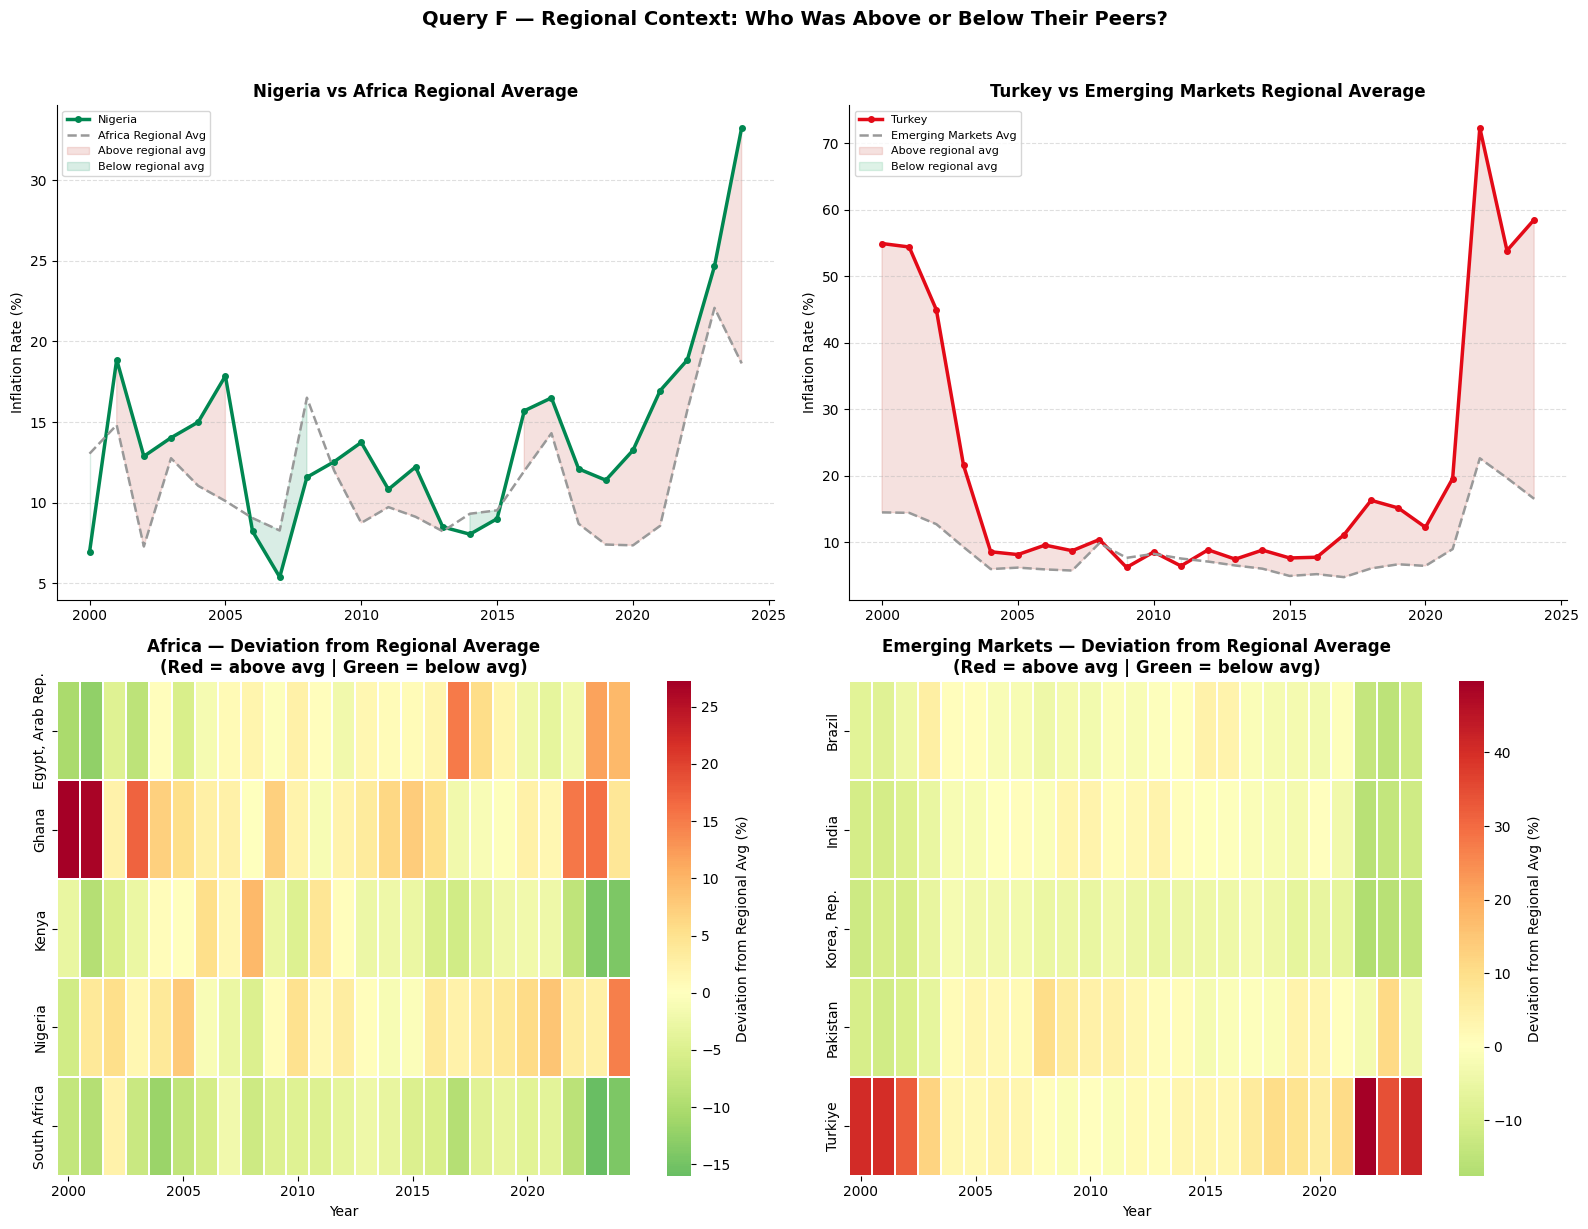

Chart saved: window_function_analysis.png


In [28]:
# Pull full dataset for charting
df_window = pd.read_sql_query("""
    SELECT
        country,
        region,
        Year,
        ROUND(Inflation_Rate, 2) AS inflation,
        ROUND(AVG(Inflation_Rate) OVER (PARTITION BY region, Year), 2)
            AS regional_avg,
        ROUND(Inflation_Rate - AVG(Inflation_Rate)
            OVER (PARTITION BY region, Year), 2) AS deviation
    FROM inflation_data
    WHERE Inflation_Rate IS NOT NULL
    ORDER BY region, country, Year
""", conn_inflation)

# CHART 1: Nigeria vs Africa regional average
df_nigeria = df_window[df_window['country'] == 'Nigeria']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top left — Nigeria vs regional average
ax = axes[0, 0]
ax.plot(df_nigeria['Year'], df_nigeria['inflation'],
        color='#008751', linewidth=2.5, marker='o',
        markersize=4, label='Nigeria')
ax.plot(df_nigeria['Year'], df_nigeria['regional_avg'],
        color='#999999', linewidth=1.8, linestyle='--',
        label='Africa Regional Avg')
ax.fill_between(df_nigeria['Year'],
                df_nigeria['inflation'],
                df_nigeria['regional_avg'],
                where=df_nigeria['inflation'] > df_nigeria['regional_avg'],
                alpha=0.15, color='#C0392B',
                label='Above regional avg')
ax.fill_between(df_nigeria['Year'],
                df_nigeria['inflation'],
                df_nigeria['regional_avg'],
                where=df_nigeria['inflation'] <= df_nigeria['regional_avg'],
                alpha=0.15, color='#008751',
                label='Below regional avg')
ax.set_title('Nigeria vs Africa Regional Average', fontweight='bold')
ax.set_ylabel('Inflation Rate (%)')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Top right — Turkey vs regional average
df_turkey = df_window[df_window['country'] == 'Turkiye']
ax = axes[0, 1]
ax.plot(df_turkey['Year'], df_turkey['inflation'],
        color='#E30A17', linewidth=2.5, marker='o',
        markersize=4, label='Turkey')
ax.plot(df_turkey['Year'], df_turkey['regional_avg'],
        color='#999999', linewidth=1.8, linestyle='--',
        label='Emerging Markets Avg')
ax.fill_between(df_turkey['Year'],
                df_turkey['inflation'],
                df_turkey['regional_avg'],
                where=df_turkey['inflation'] > df_turkey['regional_avg'],
                alpha=0.15, color='#C0392B',
                label='Above regional avg')
ax.fill_between(df_turkey['Year'],
                df_turkey['inflation'],
                df_turkey['regional_avg'],
                where=df_turkey['inflation'] <= df_turkey['regional_avg'],
                alpha=0.15, color='#27AE60',
                label='Below regional avg')
ax.set_title('Turkey vs Emerging Markets Regional Average', fontweight='bold')
ax.set_ylabel('Inflation Rate (%)')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Bottom left — Deviation heatmap for Africa
df_africa_dev = df_window[df_window['region'] == 'Africa'].pivot(
    index='country',
    columns='Year',
    values='deviation'
)

import seaborn as sns
ax = axes[1, 0]
sns.heatmap(
    df_africa_dev,
    ax=ax,
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Deviation from Regional Avg (%)'},
    xticklabels=5
)
ax.set_title('Africa — Deviation from Regional Average\n(Red = above avg | Green = below avg)',
             fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')

# Bottom right — Deviation heatmap for Emerging Markets
df_em_dev = df_window[df_window['region'] == 'Emerging Markets'].pivot(
    index='country',
    columns='Year',
    values='deviation'
)

ax = axes[1, 1]
sns.heatmap(
    df_em_dev,
    ax=ax,
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Deviation from Regional Avg (%)'},
    xticklabels=5
)
ax.set_title('Emerging Markets — Deviation from Regional Average\n(Red = above avg | Green = below avg)',
             fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')

plt.suptitle('Query F — Regional Context: Who Was Above or Below Their Peers?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('window_function_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: window_function_analysis.png")

# Exploratory Data Analysis & Visualisation

**The Time Series**

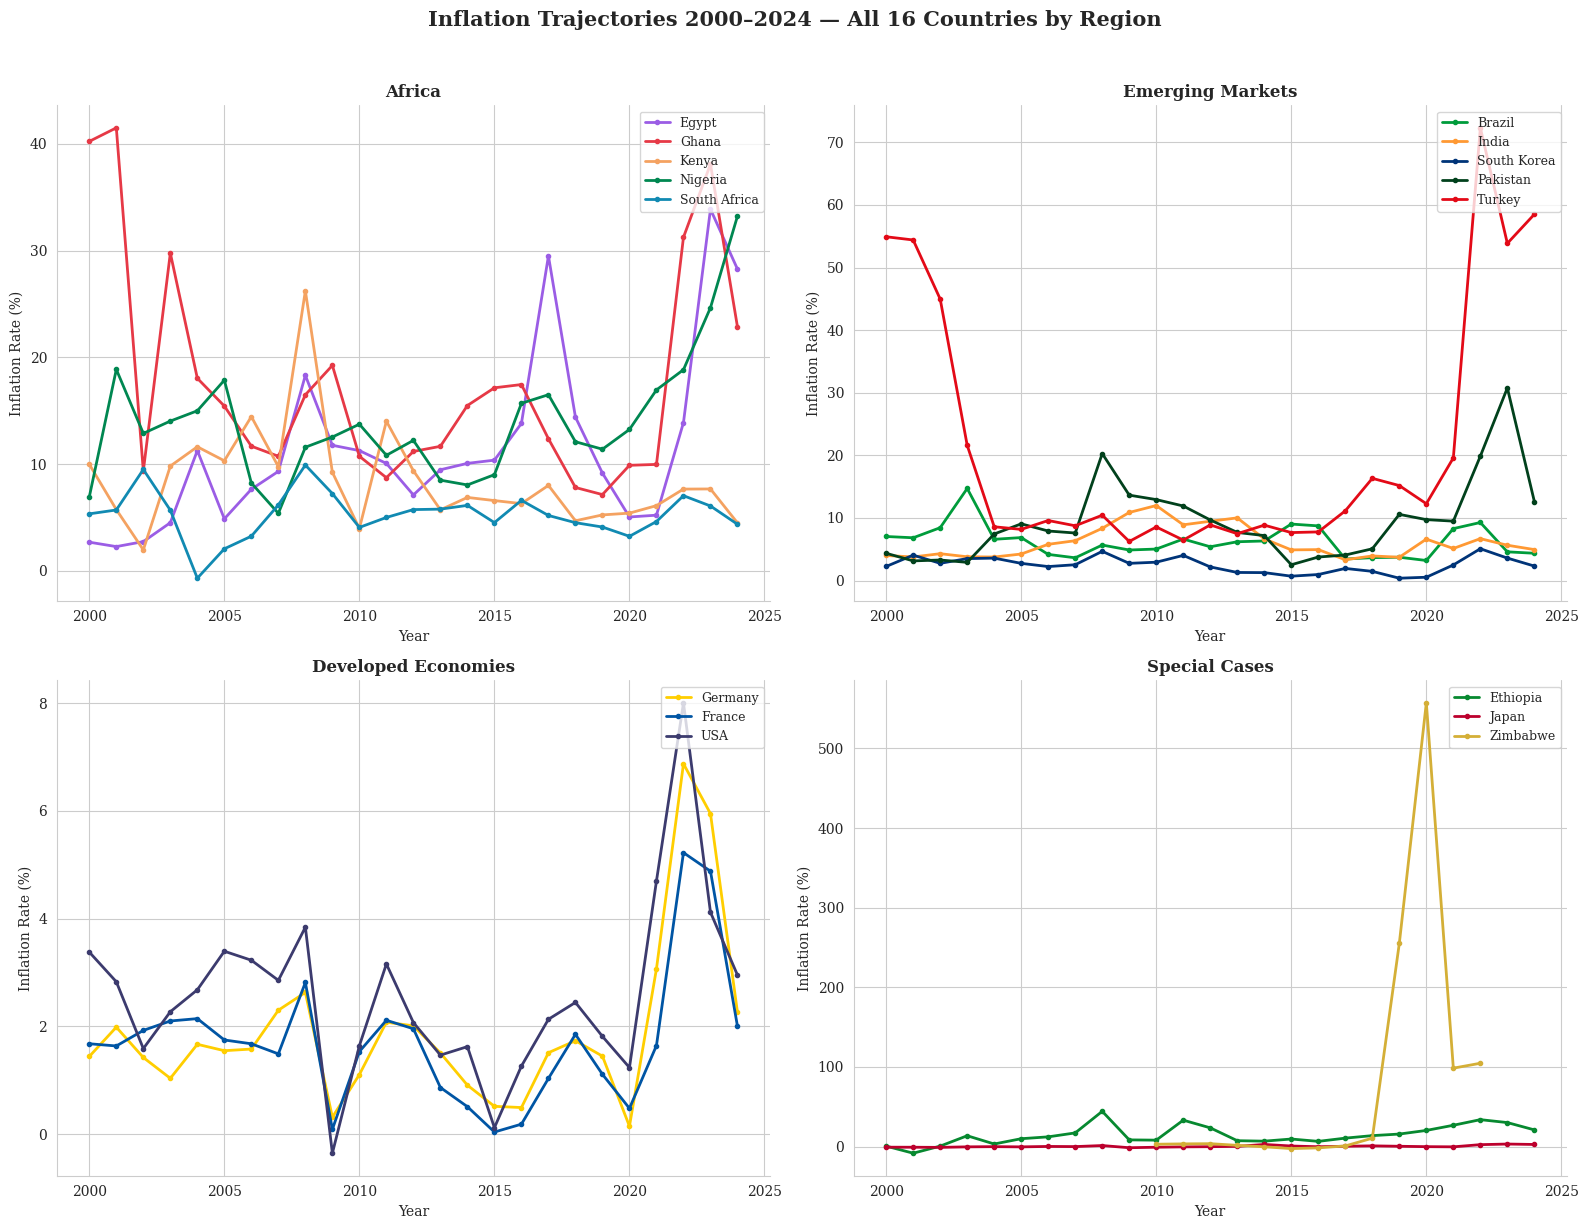

Chart 1 saved: chart1_timeseries.png


In [29]:
## How did inflation move over time for all 16 countries?

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# Colour palette
country_colors = {
    'Nigeria': '#008751',
    'Ghana': '#E63946',
    'Kenya': '#F4A261',
    'Egypt': '#9B5DE5',
    'South Africa': '#118AB2',
    'Turkey': '#E30A17',
    'Brazil': '#009C3B',
    'India': '#FF9933',
    'South Korea': '#003478',
    'Pakistan': '#01411C',
    'USA': '#3C3B6E',
    'Germany': '#FFCE00',
    'France': '#0055A4',
    'Zimbabwe': '#D4AF37',
    'Japan': '#BC002D',
    'Ethiopia': '#078930'
}

regions = ['Africa', 'Emerging Markets', 'Developed', 'Special Cases']
region_titles = {
    'Africa': 'Africa',
    'Emerging Markets': 'Emerging Markets',
    'Developed': 'Developed Economies',
    'Special Cases': 'Special Cases'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    df_region = df_analysis[df_analysis['region'] == region]

    for country in df_region['country_display'].unique():
        df_country = df_region[df_region['country_display'] == country]
        ax.plot(
            df_country['Year'],
            df_country['Inflation_Rate'],
            linewidth=2,
            marker='o',
            markersize=3,
            label=country,
            color=country_colors.get(country, '#333333')
        )

    ax.set_title(region_titles[region])
    ax.set_ylabel('Inflation Rate (%)')
    ax.set_xlabel('Year')
    ax.legend(fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Inflation Trajectories 2000–2024 — All 16 Countries by Region',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved: chart1_timeseries.png")

### The Full Inflation Heatmap

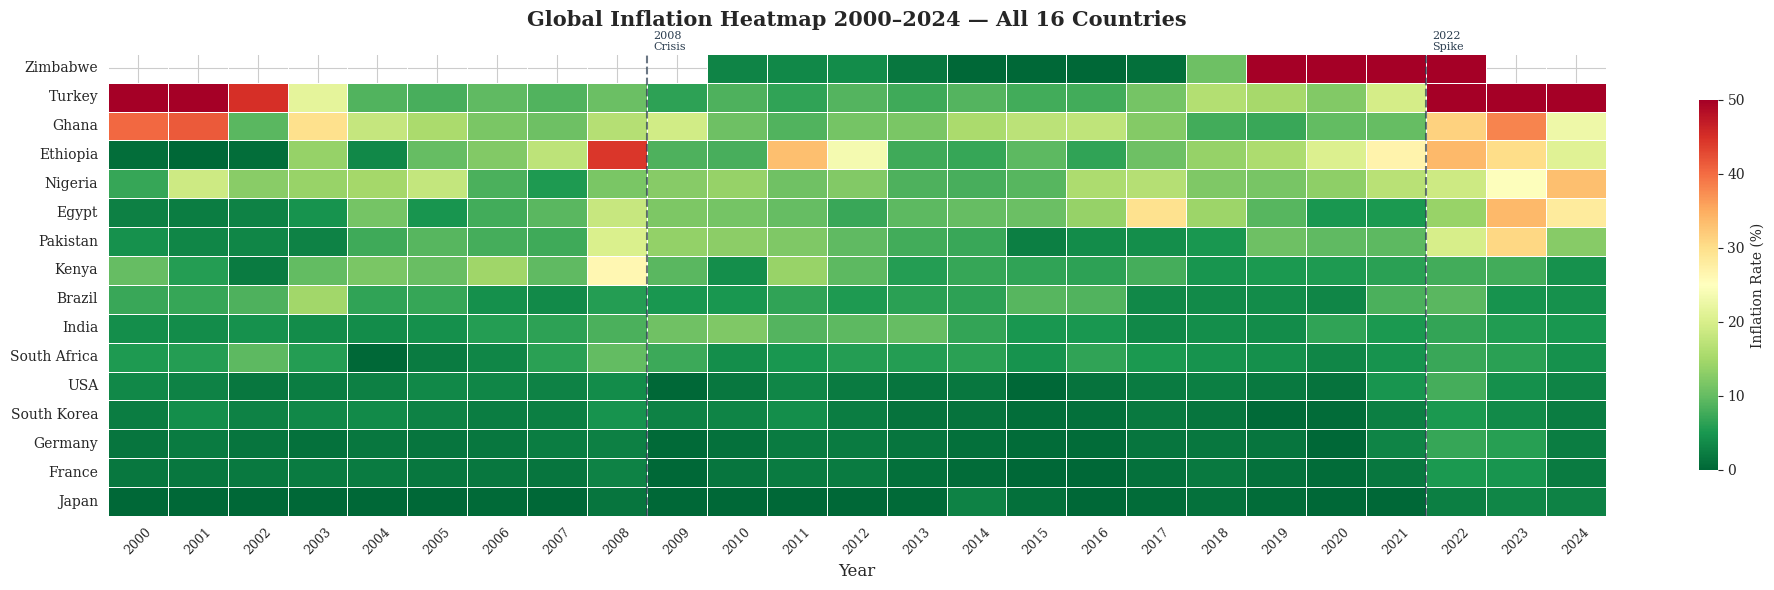

Chart 2 saved: chart2_heatmap.png


In [30]:
## What does the complete inflation picture look like across all 16 countries and all 25 years simultaneously?
# Pivoting the data: countries as rows, years as columns
df_heat = df_analysis.pivot_table(
    index='country_display',
    columns='Year',
    values='Inflation_Rate'
)

# Sorting countries by their average inflation: DESC
df_heat = df_heat.loc[df_heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(20, 6))

sns.heatmap(
    df_heat,
    ax=ax,
    cmap='RdYlGn_r',
    linewidths=0.4,
    linecolor='white',
    annot=False,
    cbar_kws={
        'label': 'Inflation Rate (%)',
        'shrink': 0.8
    },
    vmin=0,
    vmax=50
)

# Adding country colours as left spine markers
ax.set_title('Global Inflation Heatmap 2000–2024 — All 16 Countries',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9, rotation=45)

# Highlighting the 2008 and 2022 crisis columns
for year_pos, year_label in [(9, '2008\nCrisis'), (22, '2022\nSpike')]:
    ax.axvline(x=year_pos, color='#2C3E50', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(year_pos + 0.1, -0.8, year_label,
            fontsize=8, color='#2C3E50', va='top')

plt.tight_layout()
plt.savefig('chart2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved: chart2_heatmap.png")

## The Global Inflation Heatmap

This heatmap shows every country and every year simultaneously.
Each cell represents one country's inflation rate in one year, where
darker red means higher inflation, darker green means lower.

Countries are sorted from highest average inflation at the top
to lowest at the bottom, making the stability ranking immediately
visible.

Two vertical markers highlight the 2008 global financial crisis
and the 2021–2023 post-COVID inflation surge, both visible as
dark red bands cutting across nearly every country simultaneously,
confirming these were global shocks rather than country-specific problems.

Zimbabwe's extreme values are capped at 50% on the colour scale
to preserve visual contrast across the rest of the dataset.

**The Correlation Matrix**

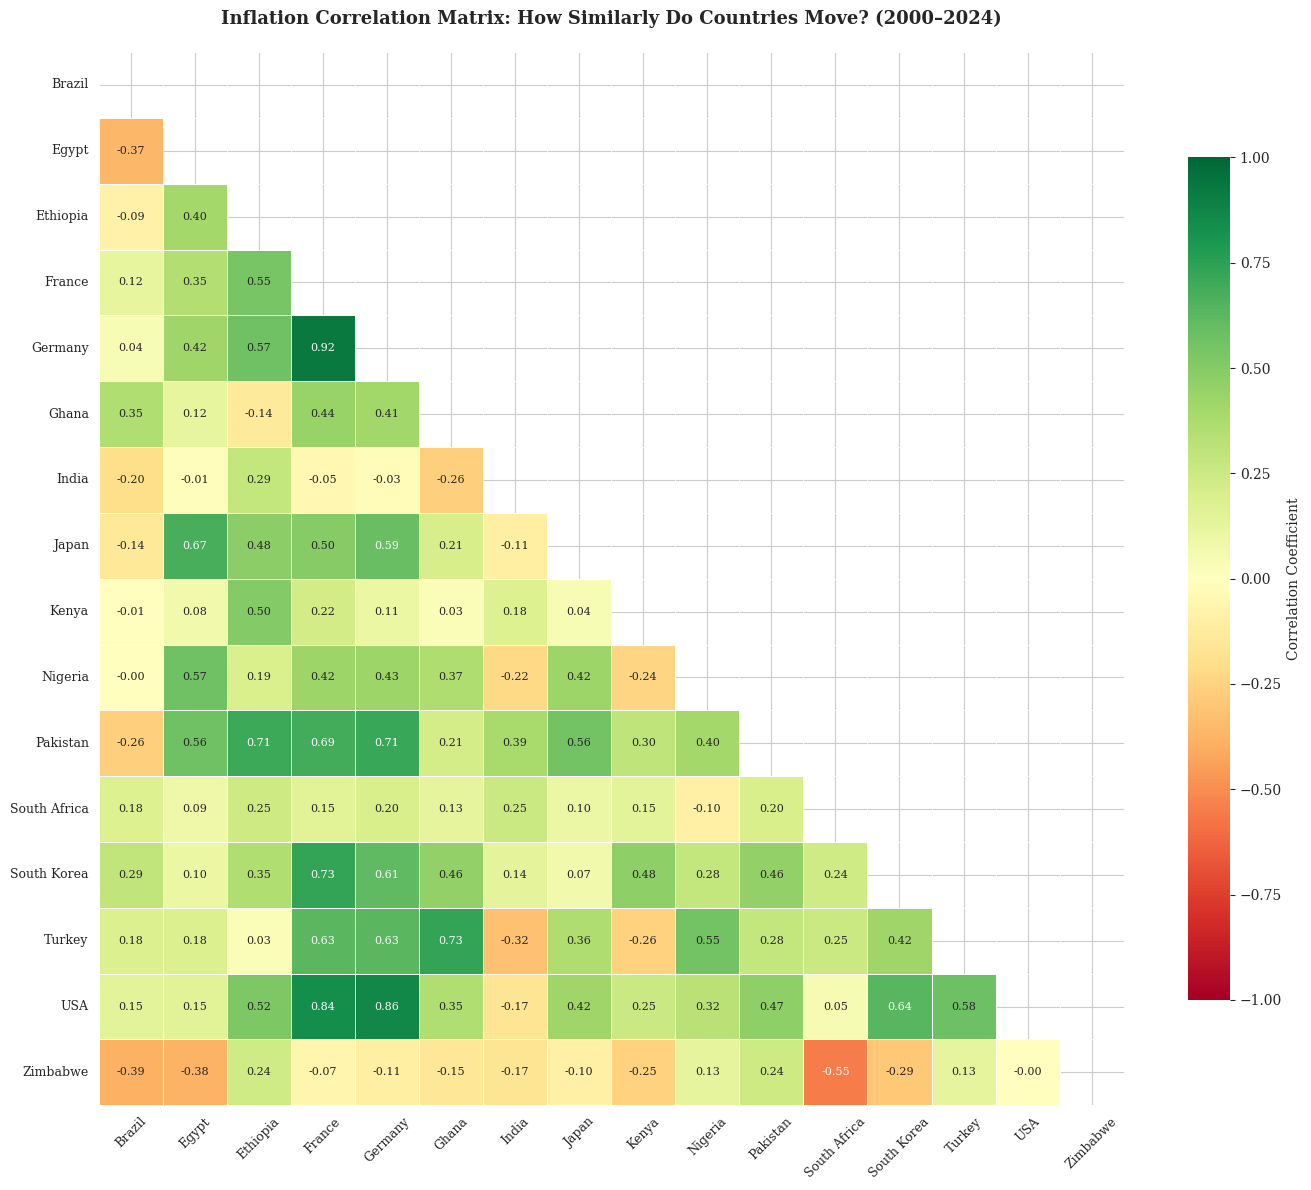

Chart 3 saved: chart3_correlation.png


In [31]:
## Which countries have inflation patterns most similar to each other?
# Pivotso each country is a column and years are rows
df_corr = df_analysis.pivot_table(
    index='Year',
    columns='country_display',
    values='Inflation_Rate'
)

# Calculating correlation between every pair of countries
corr_matrix = df_corr.corr()

# Generating mask for upper triangle to avoid showing duplicate info
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8}
)

ax.set_title('Inflation Correlation Matrix: How Similarly Do Countries Move? (2000–2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('chart3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved: chart3_correlation.png")

## Inflation Correlation Matrix

This correlation matrix answers the question of which countries experienced inflation in similar patterns over the
25-year period for every possible country pair simultaneously.

A score close to 1.0 means the two countries' inflation rates moved
closely together over time, likely sharing common external shocks
or economic structures. A score near 0 means no meaningful
relationship. A negative score means they tended to move in
opposite directions.

The upper triangle is hidden to avoid redundancy as each pair now
appears only once. The diagonal would be each country correlated
with itself (always 1.0) and is excluded for the same reason.

High correlations within a region suggest shared economic exposure.
High correlations across regions are more surprising and analytically
interesting. This correlation may point to global commodity price effects,
trade relationships, or shared monetary policy influences, especially in the case of Germany and France with a very high correlation affected by policy influences in the EU.

**Box Plot by Region**

/tmp/ipykernel_911/817788889.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


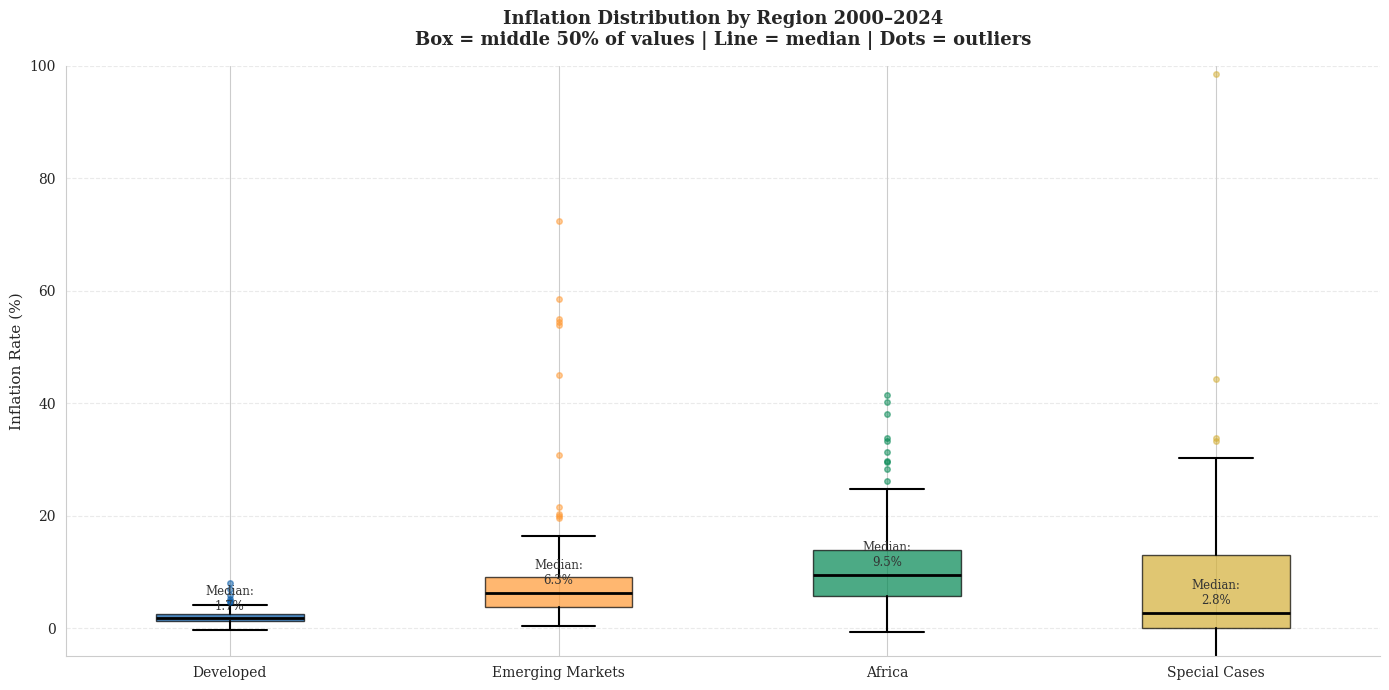

Chart 4 saved: chart4_boxplot.png


In [32]:
## How is inflation distributed within each region, and where are the outliers?
fig, ax = plt.subplots(figsize=(14, 7))

# Defining region order and colours
region_order = ['Developed', 'Emerging Markets', 'Africa', 'Special Cases']
region_colors = {
    'Developed':        '#0055A4',
    'Emerging Markets': '#FF9933',
    'Africa':           '#008751',
    'Special Cases':    '#D4AF37'
}

# One box per region
bp = ax.boxplot(
    [df_analysis[df_analysis['region'] == r]['Inflation_Rate'].dropna().values
     for r in region_order],
    labels=region_order,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

# Applying region colours to each box
for patch, region in zip(bp['boxes'], region_order):
    patch.set_facecolor(region_colors[region])
    patch.set_alpha(0.7)

# Colouring the outlier dots to match their region
for flier, region in zip(bp['fliers'], region_order):
    flier.set_markerfacecolor(region_colors[region])
    flier.set_markeredgecolor(region_colors[region])

ax.set_title('Inflation Distribution by Region 2000–2024\n'
             'Box = middle 50% of values | Line = median | Dots = outliers',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Inflation Rate (%)', fontsize=11)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(-5, 100)

# Adding median value labels
for i, region in enumerate(region_order):
    median_val = df_analysis[
        df_analysis['region'] == region
    ]['Inflation_Rate'].median()
    ax.text(
        i + 1,
        median_val + 1.5,
        f'Median:\n{median_val:.1f}%',
        ha='center',
        fontsize=8.5,
        color='#333333'
    )

plt.tight_layout()
plt.savefig('chart4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved: chart4_boxplot.png")

In [33]:
# See exactly which values are outliers in Special Cases
df_special = df_analysis[df_analysis['region'] == 'Special Cases']['Inflation_Rate'].dropna()

Q1 = df_special.quantile(0.25)
Q3 = df_special.quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + (1.5 * IQR)
lower_fence = Q1 - (1.5 * IQR)

outliers = df_special[(df_special > upper_fence) | (df_special < lower_fence)]

print(f"Q1: {Q1:.2f}%")
print(f"Q3: {Q3:.2f}%")
print(f"IQR: {IQR:.2f}")
print(f"Upper fence: {upper_fence:.2f}%")
print(f"Lower fence: {lower_fence:.2f}%")
print(f"\nNumber of outliers: {len(outliers)}")
print(f"Outlier values:\n{outliers.sort_values(ascending=False)}")

Q1: -0.02%
Q3: 12.99%
IQR: 13.00
Upper fence: 32.49%
Lower fence: -19.52%

Number of outliers: 7
Outlier values:
975     557.201817
959     255.304991
1007    104.705171
991      98.546105
771      44.356686
995      33.889880
819      33.249960
Name: Inflation_Rate, dtype: float64


## Inflation Distribution by Region

How spread out is inflation within each region, and where are
the extremes?

A box plot answers this without showing every individual data point.
The box covers the middle 50% of all values for that region across
all countries and years. The line inside is the median. Dots beyond
the whiskers are statistical outliers, years and countries where
inflation was unusually extreme relative to the group.

Key things this chart reveals:
- How tight or loose each region's inflation range is
- Whether a region's median is pulled up by a few extreme cases
  or reflects consistent behaviour across all its members
- Which regions have the most outliers — pointing to internal
  divergence rather than shared economic patterns

The y-axis is capped at 100% to preserve readability.
Zimbabwe's hyperinflation years extend far beyond this range
and appear as high outlier dots.

### The Worst Moments

In [34]:
## What were the single worst inflation episodes globally, country, year, and magnitude?
# Get top 20 worst country-year combinations
df_worst = df_analysis.nlargest(20, 'Inflation_Rate')[
    ['country_display', 'Year', 'Inflation_Rate', 'region']
].reset_index(drop=True)

print(df_worst)

   country_display  Year  Inflation_Rate            region
0         Zimbabwe  2020      557.201817     Special Cases
1         Zimbabwe  2019      255.304991     Special Cases
2         Zimbabwe  2022      104.705171     Special Cases
3         Zimbabwe  2021       98.546105     Special Cases
4           Turkey  2022       72.308836  Emerging Markets
5           Turkey  2024       58.506451  Emerging Markets
6           Turkey  2000       54.915371  Emerging Markets
7           Turkey  2001       54.400189  Emerging Markets
8           Turkey  2023       53.859409  Emerging Markets
9           Turkey  2002       44.964121  Emerging Markets
10        Ethiopia  2008       44.356686     Special Cases
11           Ghana  2001       41.509496            Africa
12           Ghana  2000       40.240933            Africa
13           Ghana  2023       38.106966            Africa
14        Ethiopia  2022       33.889880     Special Cases
15           Egypt  2023       33.884776            Afri

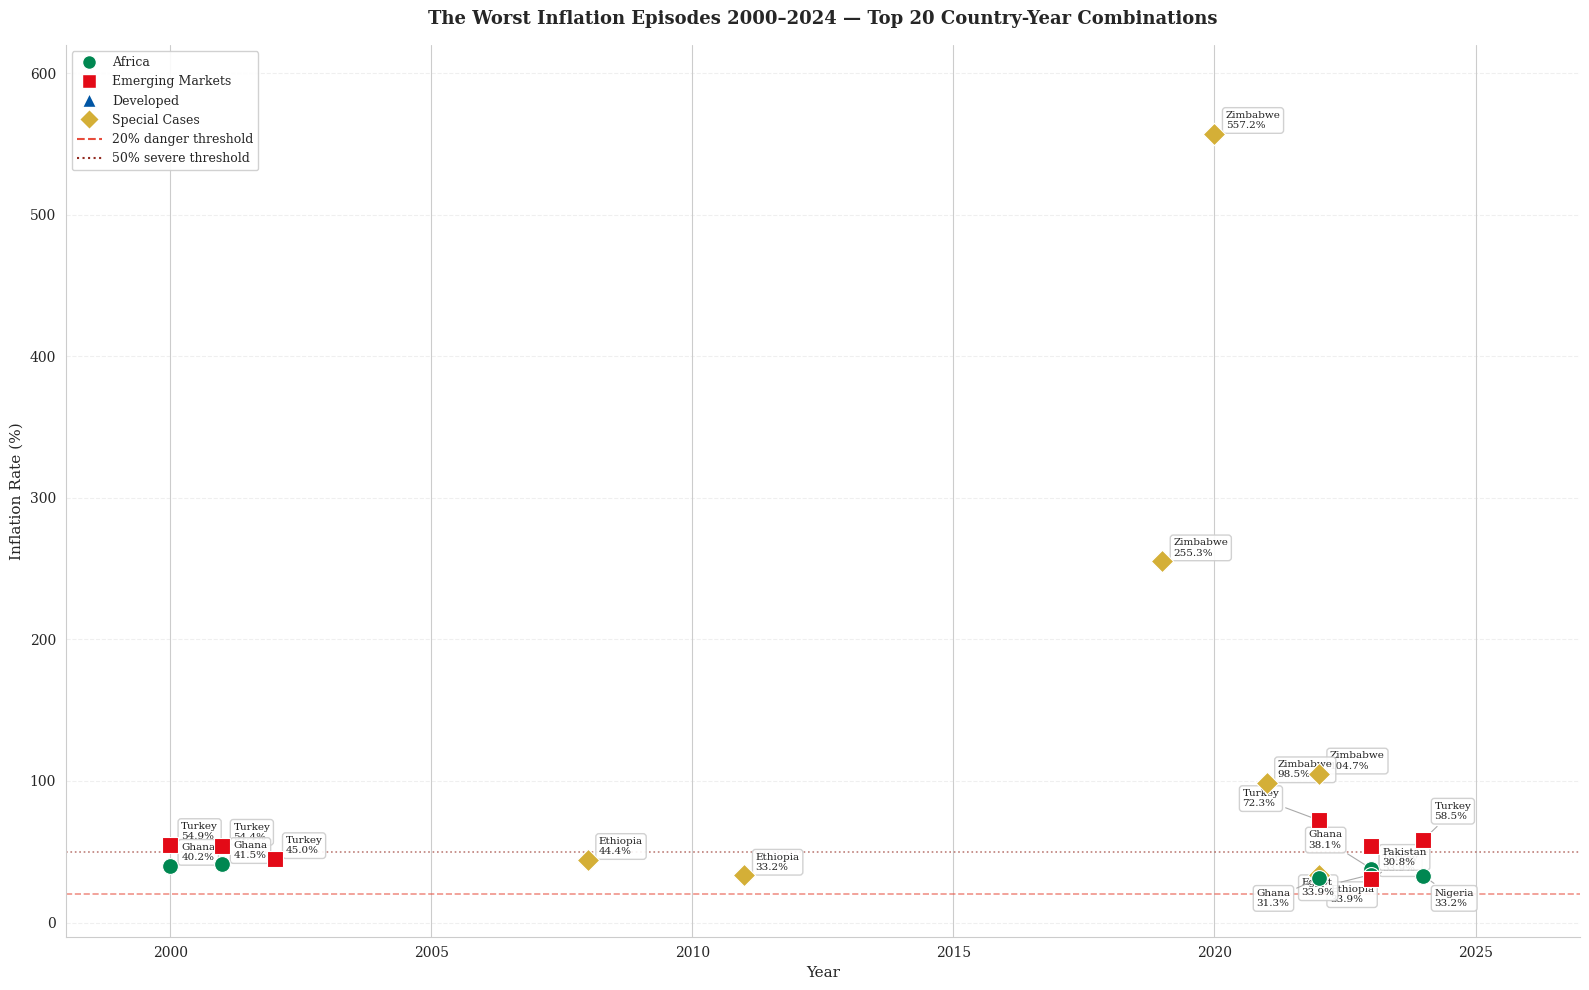

Chart 5 saved: chart5_worst_episodes.png


In [35]:
# Custom offsets for crowded points
custom_offsets = {
    'Ghana_2023':    (-45, 15),
    'Ghana_2022':    (-45, -20),
    'Nigeria_2024':  (8, -22),
    'Pakistan_2023': (8, 10),
    'Egypt_2023':    (-50, -15),
    'Ethiopia_2022': (8, -20),
    'Turkey_2024':   (8, 15),
    'Turkey_2023':   (8, -18),
    'Turkey_2022':   (-55, 10),
}

marker_shapes = {
    'Africa':           'o',
    'Emerging Markets': 's',
    'Developed':        '^',
    'Special Cases':    'D'
}

region_colors_scatter = {
    'Africa':           '#008751',
    'Emerging Markets': '#E30A17',
    'Developed':        '#0055A4',
    'Special Cases':    '#D4AF37'
}

# Get top 20 worst country-year combinations
df_worst = df_analysis.nlargest(20, 'Inflation_Rate')[
    ['country_display', 'Year', 'Inflation_Rate', 'region']
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 10))

for _, row in df_worst.iterrows():
    color = region_colors_scatter.get(row['region'], '#333333')
    marker = marker_shapes.get(row['region'], 'o')

    ax.scatter(
        row['Year'],
        row['Inflation_Rate'],
        color=color,
        s=130,
        zorder=5,
        marker=marker,
        edgecolors='white',
        linewidths=0.8
    )

    key = f"{row['country_display']}_{row['Year']}"
    offset = custom_offsets.get(key, (8, 4))

    ax.annotate(
        f"{row['country_display']}\n{row['Inflation_Rate']:.1f}%",
        xy=(row['Year'], row['Inflation_Rate']),
        xytext=offset,
        textcoords='offset points',
        fontsize=7.5,
        color='#222222',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='#CCCCCC',
            alpha=0.9
        ),
        arrowprops=dict(
            arrowstyle='-',
            color='#AAAAAA',
            lw=0.8
        )
    )

# Threshold lines
ax.axhline(y=20, color='#E74C3C', linewidth=1.2,
           linestyle='--', alpha=0.6, label='20% danger threshold')
ax.axhline(y=50, color='#922B21', linewidth=1.2,
           linestyle=':', alpha=0.6, label='50% severe threshold')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker=marker_shapes[r], color='w',
           markerfacecolor=c, markersize=10, label=r)
    for r, c in region_colors_scatter.items()
] + [
    Line2D([0], [0], color='#E74C3C', linewidth=1.5,
           linestyle='--', label='20% danger threshold'),
    Line2D([0], [0], color='#922B21', linewidth=1.5,
           linestyle=':', label='50% severe threshold')
]
ax.legend(handles=legend_elements, fontsize=9,
          loc='upper left', framealpha=0.9)

ax.set_title('The Worst Inflation Episodes 2000–2024 — Top 20 Country-Year Combinations',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Inflation Rate (%)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_xlim(1998, 2027)
ax.set_ylim(-10, 620)

plt.tight_layout()
plt.savefig('chart5_worst_episodes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved: chart5_worst_episodes.png")

## The Worst Inflation Episodes

Which country-year combinations produced the most extreme inflation
rates in the dataset? This chart places every top-20 episode in
time, annotated with the country name and exact rate.

Two threshold lines provide context:
- The 20% danger line marks where inflation begins causing serious
  damage to household purchasing power and business planning
- The 50% severe line marks near-hyperinflationary territory

Key findings visible in this chart:
- Zimbabwe accounts for the top 4 episodes, all post-2019,
  suggesting a second wave of instability after the 2009 currency
  abandonment
- Turkey appears 6 times across two completely separate eras —
  2000–2002 and 2022–2024 — two distinct crises separated by
  nearly two decades of relative stability
- Nigeria's 2024 entry at position 17 represents the country's
  highest inflation rate in the entire 25-year dataset,
  making this not just historical analysis but a live finding
- Ghana's four appearances receive far less international attention
  than Nigeria's inflation story despite comparable severity

In [36]:
import os

charts = [
    'chart1_timeseries.png',
    'chart2_heatmap.png',
    'chart3_correlation.png',
    'chart4_boxplot.png',
    'chart5_worst_episodes.png',
    'inflation_clean.csv',
    'inflation.db'
]

print("📁 File Check:")
for f in charts:
    exists = os.path.exists(f)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {f}")

📁 File Check:
  ✅  chart1_timeseries.png
  ✅  chart2_heatmap.png
  ✅  chart3_correlation.png
  ✅  chart4_boxplot.png
  ✅  chart5_worst_episodes.png
  ✅  inflation_clean.csv
  ✅  inflation.db


In [ ]:
from google.colab import files
files.download('inflation_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>